In [6]:
BDC_PATH      = "../data/VD_bdc_chunks.json"          
PSC_PATH      = "../data/VD_psc_chunks.json"         
VULGATE_PATH  = "../data/vulgate_chunks.json"      
GT_PATH       = "../data/ir_ground_truth.json"       

THRESHOLDS = [0.75, 0.85, 0.95, 1.00]

In [7]:
import json
import statistics
from pathlib import Path
from collections import defaultdict
from tqdm.notebook import tqdm
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

plt.rcParams.update({
    'figure.dpi': 130,
    'font.family': 'serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

In [8]:
def load_json_chunks(path: str) -> list:
    with open(path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    # support both {"chunks": [...]} and plain list
    return data.get('chunks', data) if isinstance(data, dict) else data


def load_jsonl_chunks(path: str) -> list:
    chunks = []
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line:
                chunks.append(json.loads(line))
    return chunks


def load_chunks(path: str) -> list:
    p = Path(path)
    if p.suffix == '.jsonl':
        chunks = load_jsonl_chunks(path)
    else:
        chunks = load_json_chunks(path)
    print(f"  {p.name}: {len(chunks):,} chunks")
    return chunks


print("Loading corpora...")
bdc_chunks     = load_chunks(BDC_PATH)
psc_chunks     = load_chunks(PSC_PATH)
vulgate_chunks = load_chunks(VULGATE_PATH)

print("\nLoading ground truth...")
with open(GT_PATH, 'r', encoding='utf-8') as f:
    gt_data = json.load(f)
gt_entries = gt_data.get('ground_truth', [])
print(f"  ground_truth.json: {len(gt_entries)} entries")

Loading corpora...
  VD_bdc_chunks.json: 19,466 chunks
  VD_psc_chunks.json: 46,408 chunks
  vulgate_chunks.json: 35,809 chunks

Loading ground truth...
  ground_truth.json: 100 entries


## 2. Build Vulgate Lemma Index

In [9]:
def get_tokens(chunk: dict) -> set:
    """Return a set of clean lowercase tokens.
    Prefers 'lemmatized' list; falls back to whitespace-split 'text'."""
    lemmas = chunk.get('lemmatized', [])
    if lemmas:
        return {t.lower() for t in lemmas if t and isinstance(t, str) and t.isalpha()}
    text = chunk.get('text', '')
    return {t.lower() for t in text.split() if t.isalpha()}


print("Building Vulgate lemma index...")
vulgate_sets = []
for verse in tqdm(vulgate_chunks, desc="Indexing Vulgate"):
    s = get_tokens(verse)
    if s:
        vulgate_sets.append(s)

print(f"  Indexed {len(vulgate_sets):,} non-empty Vulgate verses")

Building Vulgate lemma index...


Indexing Vulgate:   0%|          | 0/35809 [00:00<?, ?it/s]

  Indexed 35,809 non-empty Vulgate verses


## 3. Compute Max Overlap Score per Chunk

In [10]:
def max_overlap_score(chunk_tokens: set, verse_sets: list) -> float:
    """Max Overlap Coefficient of chunk against all Vulgate verses."""
    if not chunk_tokens:
        return 0.0
    best = 0.0
    for v in verse_sets:
        denom = min(len(chunk_tokens), len(v))
        if denom == 0:
            continue
        score = len(chunk_tokens & v) / denom
        if score > best:
            best = score
        if best == 1.0:
            break
    return best


def score_corpus(chunks: list, label: str) -> dict:
    """Returns {chunk_id: max_overlap_score} for all chunks."""
    scores = {}
    for chunk in tqdm(chunks, desc=f"Scoring {label}"):
        cid = chunk.get('chunk_id', chunk.get('id', ''))
        tokens = get_tokens(chunk)
        scores[cid] = max_overlap_score(tokens, vulgate_sets)
    return scores


print("Computing overlap scores")
bdc_scores = score_corpus(bdc_chunks, 'BDC')
psc_scores = score_corpus(psc_chunks, 'PSC')
print("\nDone.")

Computing overlap scores


Scoring BDC:   0%|          | 0/19466 [00:00<?, ?it/s]

Scoring PSC:   0%|          | 0/46408 [00:00<?, ?it/s]


Done.


In [20]:
retention_rows = []

for t in THRESHOLDS:
    bdc_kept = {cid for cid, s in bdc_scores.items() if s < t}
    psc_kept = {cid for cid, s in psc_scores.items() if s < t}

    retention_rows.append({
        'threshold':        t,
        'bdc_total':        len(bdc_scores),
        'bdc_kept':         len(bdc_kept),
        'bdc_filtered':     len(bdc_scores) - len(bdc_kept),
        'bdc_kept_pct':     round(len(bdc_kept) / len(bdc_scores) * 100, 1),
        'psc_total':        len(psc_scores),
        'psc_kept':         len(psc_kept),
        'psc_filtered':     len(psc_scores) - len(psc_kept),
        'psc_kept_pct':     round(len(psc_kept) / len(psc_scores) * 100, 1),
    })

df_retention = pd.DataFrame(retention_rows)
display(df_retention)

,threshold,bdc_total,bdc_kept,bdc_filtered,bdc_kept_pct,psc_total,psc_kept,psc_filtered,psc_kept_pct
0,0.75,19466,12730,6736,65.4,46408,35889,10519,77.3
1,0.85,19466,16527,2939,84.9,46408,45014,1394,97.0
2,0.95,19466,17310,2156,88.9,46408,45428,980,97.9
3,1.00,19466,17311,2155,88.9,46408,45428,980,97.9


In [21]:
# ground truth loss = if query chunk (BDC) or any candidate chunks (PSC) was filtereted out

# Pre-extract GT structure
gt_query_ids    = [e['query_chunk_id'] for e in gt_entries]
gt_cand_ids     = [e.get('relevant_chunks', []) for e in gt_entries]
gt_types        = [e.get('reference_type', 'unknown') for e in gt_entries]

gt_rows = []

for t in THRESHOLDS:
    bdc_kept = {cid for cid, s in bdc_scores.items() if s < t}
    psc_kept = {cid for cid, s in psc_scores.items() if s < t}

    usable = 0
    lost_query   = 0
    lost_cand    = 0
    lost_both    = 0
    usable_exp   = 0
    usable_imp   = 0
    lost_exp     = 0
    lost_imp     = 0

    for qid, cids, rtype in zip(gt_query_ids, gt_cand_ids, gt_types):
        q_ok = qid in bdc_kept
        c_ok = all(c in psc_kept for c in cids)

        if q_ok and c_ok:
            usable += 1
            if rtype == 'explicit':   usable_exp += 1
            elif rtype == 'implicit': usable_imp += 1
        else:
            if not q_ok and not c_ok: lost_both += 1
            elif not q_ok:            lost_query += 1
            else:                     lost_cand  += 1
            if rtype == 'explicit':   lost_exp += 1
            elif rtype == 'implicit': lost_imp += 1

    total = len(gt_entries)
    gt_rows.append({
        'threshold':      t,
        'total_gt':       total,
        'usable':         usable,
        'lost':           total - usable,
        'usable_pct':     round(usable / total * 100, 1),
        'lost_pct':       round((total - usable) / total * 100, 1),
        'lost_via_query': lost_query,
        'lost_via_cand':  lost_cand,
        'lost_via_both':  lost_both,
        'usable_explicit': usable_exp,
        'usable_implicit': usable_imp,
        'lost_explicit':  lost_exp,
        'lost_implicit':  lost_imp,
    })

df_gt = pd.DataFrame(gt_rows)
display(df_gt)

,threshold,total_gt,usable,lost,usable_pct,lost_pct,lost_via_query,lost_via_cand,lost_via_both,usable_explicit,usable_implicit,lost_explicit,lost_implicit
0,0.75,100,32,68,32.0,68.0,31,22,15,11,21,39,29
1,0.85,100,78,22,78.0,22.0,20,2,0,35,43,15,7
2,0.95,100,85,15,85.0,15.0,14,1,0,40,45,10,5
3,1.00,100,85,15,85.0,15.0,14,1,0,40,45,10,5


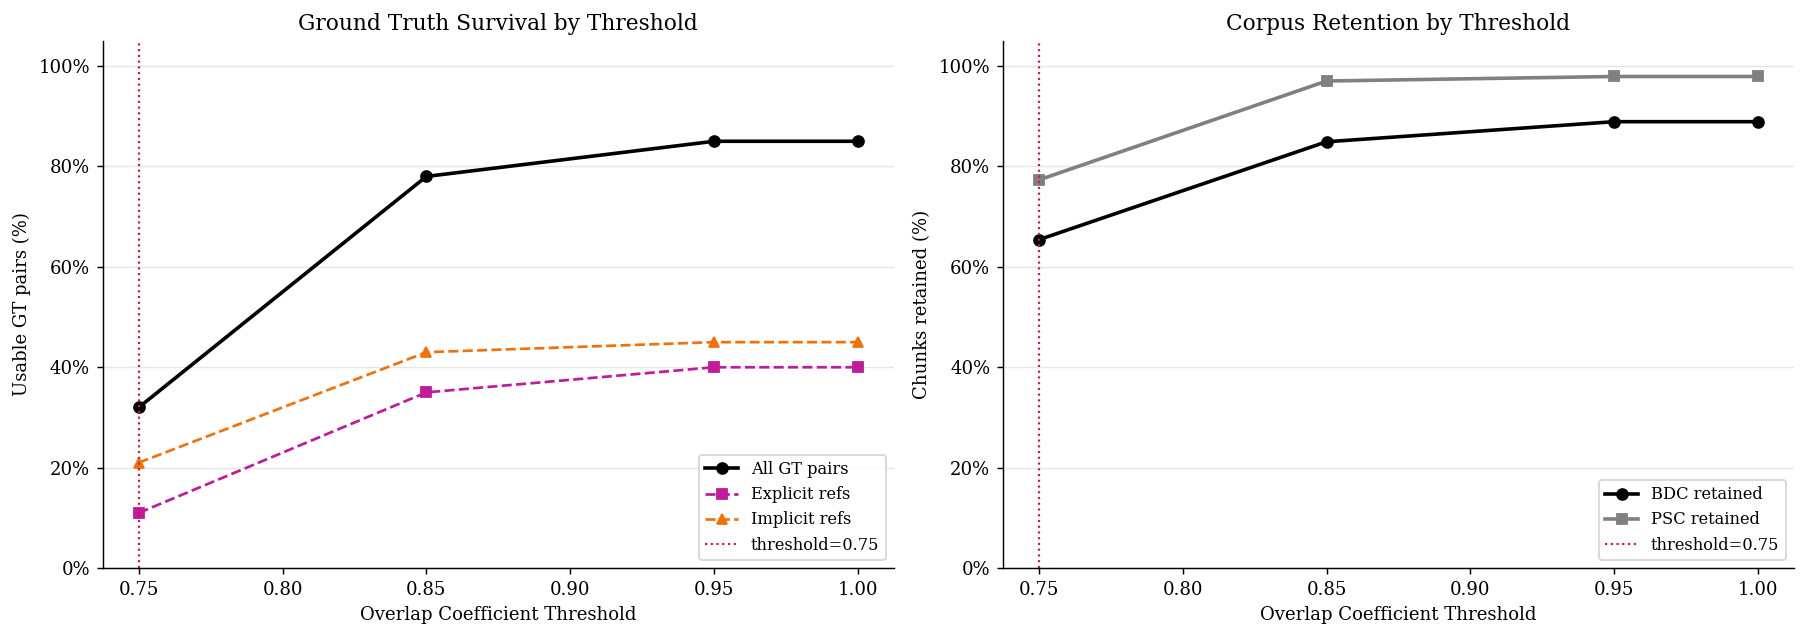

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(df_gt['threshold'], df_gt['usable_pct'], 'o-', color='black',  label='All GT pairs', linewidth=2)
ax.plot(df_gt['threshold'],
        df_gt['usable_explicit'] / df_gt['total_gt'] * 100,
        's--', color='#C11A9A', label='Explicit refs', linewidth=1.5)
ax.plot(df_gt['threshold'],
        df_gt['usable_implicit'] / df_gt['total_gt'] * 100,
        '^--', color='#F27209', label='Implicit refs', linewidth=1.5)
ax.axvline(0.75, color='crimson', linestyle=':', linewidth=1.2, label='threshold=0.75')
ax.set_xlabel('Overlap Coefficient Threshold')
ax.set_ylabel('Usable GT pairs (%)')
ax.set_title('Ground Truth Survival by Threshold')
ax.set_ylim(0, 105)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

ax2 = axes[1]
ax2.plot(df_retention['threshold'], df_retention['bdc_kept_pct'], 'o-', color='black',  label='BDC retained', linewidth=2)
ax2.plot(df_retention['threshold'], df_retention['psc_kept_pct'], 's-', color='grey', label='PSC retained', linewidth=2)
ax2.axvline(0.75, color='crimson', linestyle=':', linewidth=1.2, label='threshold=0.75')
ax2.set_xlabel('Overlap Coefficient Threshold')
ax2.set_ylabel('Chunks retained (%)')
ax2.set_title('Corpus Retention by Threshold')
ax2.set_ylim(0, 105)
ax2.yaxis.set_major_formatter(mticker.PercentFormatter())
ax2.legend(fontsize=9)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/threshold_analysis.png', bbox_inches='tight')
plt.show()

In [22]:
summary = df_gt[['threshold', 'usable', 'lost', 'usable_pct',
                  'lost_explicit', 'lost_implicit']].copy()
summary = summary.merge(
    df_retention[['threshold', 'bdc_kept_pct', 'psc_kept_pct']],
    on='threshold'
)
summary.columns = [
    'Threshold', 'GT Usable', 'GT Lost', 'GT Usable %',
    'Explicit Lost', 'Implicit Lost',
    'BDC Retained %', 'PSC Retained %'
]

print(summary.to_string(index=False))

# save as CSV
summary.to_csv('../vulgate-filtering/filtering_threshold_summary.csv', index=False)

 Threshold  GT Usable  GT Lost  GT Usable %  Explicit Lost  Implicit Lost  BDC Retained %  PSC Retained %
      0.75         32       68         32.0             39             29            65.4            77.3
      0.85         78       22         78.0             15              7            84.9            97.0
      0.95         85       15         85.0             10              5            88.9            97.9
      1.00         85       15         85.0             10              5            88.9            97.9
